In [3]:
import MDAnalysis as mda
import MDAnalysis.analysis.msd as msd
from MDAnalysis.analysis.rdf import InterRDF
from MDAnalysis.transformations import NoJump
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
import mdtraj as mdtraj

/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.11/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(
/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.11/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it ha

In [1]:
## Convert ase trajectory
# ! ase convert ../output/2l_water_grace_small_b_off_run1/water_300_nvt.traj ../output/2l_water_grace_small_b_off_run1/water_300_nvt.pdb
# ! ase convert ../output/2l_water_grace_medium_b_off_run1/water_300_nvt.traj ../output/2l_water_grace_medium_b_off_run1/water_300_nvt.pdb
# Acetone
# ! ase convert ../output/2l_acetone_grace_small_b_off_run1/acetone_300_nvt.traj ../output/2l_acetone_grace_small_b_off_run1/acetone_300_nvt.pdb
# ! ase convert ../output/2l_acetone_grace_medium_b_off_run1/acetone_300_nvt.traj ../output/2l_acetone_grace_medium_b_off_run1/acetone_300_npt.pdb 
# Hexane
! rm ../output/2l_hexane_grace_small_b_off_run1/hexane_300_nvt.pdb
! rm ../output/2l_hexane_grace_medium_b_off_run1/hexane_300_nvt.pdb
! ase convert ../output/2l_hexane_grace_small_b_off_run1/hexane_300_nvt.traj ../output/2l_hexane_grace_small_b_off_run1/hexane_300_nvt.pdb
! ase convert ../output/2l_hexane_grace_medium_b_off_run1/hexane_300_nvt.traj ../output/2l_hexane_grace_medium_b_off_run1/hexane_300_nvt.pdb
# # Benzene
! rm ../output/2l_benzene_grace_small_b_off_run1/benzene_300_nvt.pdb
! rm ../output/2l_benzene_grace_medium_b_off_run1/benzene_300_nvt.pdb
! ase convert ../output/2l_benzene_grace_small_b_off_run1/benzene_300_nvt.traj ../output/2l_benzene_grace_small_b_off_run1/benzene_300_nvt.pdb
! ase convert ../output/2l_benzene_grace_medium_b_off_run1/benzene_300_nvt.traj ../output/2l_benzene_grace_medium_b_off_run1/benzene_300_nvt.pdb
# # Methanol
# ! ase convert ../output/2l_methanol_grace_small_b_off_run1/methanol_300_nvt.traj ../output/2l_methanol_grace_small_b_off_run1/methanol_300_nvt.pdb
# ! ase convert ../output/2l_methanol_grace_medium_b_off_run1/methanol_300_nvt.traj ../output/2l_methanol_grace_medium_b_off_run1/methanol_300_nvt.pdb

/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.11/site-packages/MDAnalysis/analysis/base.py:562: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time
100%|██████████| 1716/1716 [00:14<00:00, 115.88it/s]



Self Diffusion for model water grace small: 0.21773602235559428 A^2/ps
Self Diffusion for model water grace small: 2.177360223555943e-09 m^2/s


100%|██████████| 1716/1716 [00:14<00:00, 118.42it/s]



Self Diffusion for model water grace medium: 0.20378171009984927 A^2/ps
Self Diffusion for model water grace medium: 2.037817100998493e-09 m^2/s


100%|██████████| 1780/1780 [00:15<00:00, 114.89it/s]



...

Self Diffusion for model benzene grace medium: 0.46289431293044586 A^2/ps
Self Diffusion for model benzene grace medium: 4.628943129304459e-09 m^2/s


100%|██████████| 1938/1938 [00:16<00:00, 114.26it/s]



Self Diffusion for model methanol grace small: 0.2830264592202035 A^2/ps
Self Diffusion for model methanol grace small: 2.8302645922020347e-09 m^2/s


100%|██████████| 1938/1938 [00:16<00:00, 114.14it/s]



Self Diffusion for model methanol grace medium: 0.24130937877524705 A^2/ps
Self Diffusion for model methanol grace medium: 2.4130937877524706e-09 m^2/s


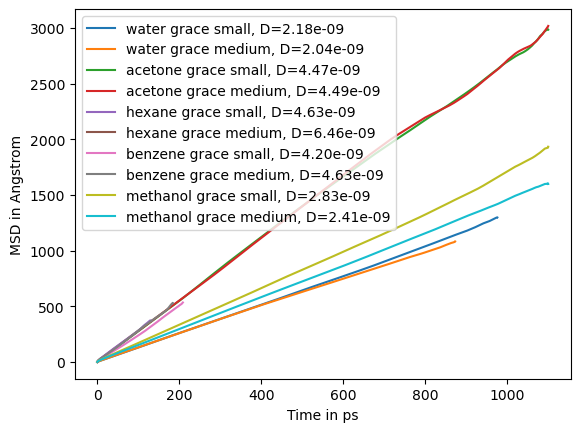

Saved diffusion results to diffusion_results.csv


In [ ]:
import pandas as pd

traj = {
    "water grace small": "../output/2l_water_grace_small_b_off_run1/water_300_nvt.pdb",
    "water grace medium": "../output/2l_water_grace_medium_b_off_run1/water_300_nvt.pdb",
    "acetone grace small": "../output/2l_acetone_grace_small_b_off_run1/acetone_300_nvt.pdb",
    "acetone grace medium": "../output/2l_acetone_grace_medium_b_off_run1/acetone_300_npt.pdb",
    "hexane grace small": "../output/2l_hexane_grace_small_b_off_run1/hexane_300_nvt.pdb",
    "hexane grace medium": "../output/2l_hexane_grace_medium_b_off_run1/hexane_300_nvt.pdb",
    "benzene grace small": "../output/2l_benzene_grace_small_b_off_run1/benzene_300_nvt.pdb",
    "benzene grace medium": "../output/2l_benzene_grace_medium_b_off_run1/benzene_300_nvt.pdb",
    "methanol grace small": "../output/2l_methanol_grace_small_b_off_run1/methanol_300_nvt.pdb",
    "methanol grace medium": "../output/2l_methanol_grace_medium_b_off_run1/methanol_300_nvt.pdb",
}

diffusion_data = []

for model, path in traj.items():
    universe = mda.Universe(path)
    atoms = universe.atoms
    transform = NoJump(atoms)
    universe.trajectory.add_transformations(transform)
    MSD_mm = msd.EinsteinMSD(universe, select="all", msd_type="xyz", fft=True)
    MSD_mm.run(step=1)

    result_mm = MSD_mm.results.timeseries
    msd_all = result_mm
    nframes = MSD_mm.n_frames
    timestep = 0.05  # in ps,  this needs to be the actual time between frames
    lagtimes = np.arange(nframes) * timestep  # make the lag-time axis
    lag = lagtimes
    # plot the actual MSD
    # plt.show()

    # linear_model = linregress(lagtimes[500:-100], result_mm[500:-100])
    linear_model = linregress(lagtimes, result_mm)
    slope = linear_model.slope
    error = linear_model.stderr
    D = slope / 6
    print(f"Self Diffusion for model {model}: {D} A^2/ps")
    print(f"Self Diffusion for model {model}: {D*10**-8} m^2/s")
    diffusion = D * 10**-8
    
    # Parse solute and model from the key
    parts = model.split()
    solute = parts[0].capitalize()
    model_name = " ".join(parts[1:]).upper() if len(parts) > 1 else "GRACE"
    
    diffusion_data.append({"solute": solute, "model": model_name, "D_A2_ps": D, "D_m2_s": diffusion})

    plt.plot(
        lagtimes,
        result_mm,
        label=f'{model.split("/")[-1].split(".")[0]}, D={diffusion:.2e}',
    )
    plt.ylabel("MSD in Angstrom")
    plt.xlabel("Time in ps")

    # ANI diffusion
plt.legend()
plt.show()

# Save results to CSV
df_diffusion = pd.DataFrame(diffusion_data)

# Add experimental and MACE-OFF23(S) values
# Values are in 10^-9 m^2/s
experimental_values = {
    "Water": 2.29,
    "Methanol": 2.27,
    "Acetone": 4.94,
    "Benzene": 2.15,
    "n-Hexane": 4.14
}

mace_off23s_values = {
    "Water": 2.20,
    "Methanol": 5.75 * 10**1,
    "Acetone": 1.14,
    "Benzene": 2.06 * 10**-1,
    "n-Hexane": 9.66 * 10**-2
}

additional_data = []
for molecule, val in mace_off23s_values.items():
    d_m2_s = val * 10**-9
    d_a2_ps = d_m2_s * 10**8
    additional_data.append({"solute": molecule, "model": "MACE-OFF23(S)", "D_A2_ps": d_a2_ps, "D_m2_s": d_m2_s})
    
for molecule, val in experimental_values.items():
    d_m2_s = val * 10**-9
    # 1 m^2/s = 10^8 A^2/ps
    d_a2_ps = d_m2_s * 10**8
    additional_data.append({"solute": molecule, "model": "Experiment", "D_A2_ps": d_a2_ps, "D_m2_s": d_m2_s})


df_additional = pd.DataFrame(additional_data)
df_diffusion = pd.concat([df_diffusion, df_additional], ignore_index=True)

df_diffusion.to_csv("diffusion/diffusion_results.csv", index=False)
print("Saved diffusion results to diffusion/diffusion_results.csv")

In [10]:
df_diffusion['solute'] = df_diffusion['solute'].replace('Hexane', 'n-Hexane')
df_diffusion_droped = df_diffusion.drop([10])

In [11]:
df_diffusion

,solute,model,D_A2_ps,D_m2_s
0,n-Hexane,GRACE SMALL,0.463445,4.634445e-09
1,n-Hexane,GRACE MEDIUM,0.645733,6.457330e-09
2,Benzene,GRACE SMALL,0.419652,4.196517e-09
3,Benzene,GRACE MEDIUM,0.462894,4.628943e-09
4,Water,Experiment,0.229000,2.290000e-09
5,Methanol,Experiment,0.227000,2.270000e-09
6,Acetone,Experiment,0.494000,4.940000e-09
7,Benzene,Experiment,0.215000,2.150000e-09
8,n-Hexane,Experiment,0.414000,4.140000e-09
9,Water,MACE-OFF23(S),0.220000,2.200000e-09


In [1]:
# Create a scatter plot with solutes on x-axis and models as different series
fig, ax = plt.subplots(figsize=(6, 4))

# Get unique models and solutes
models = df_diffusion_droped['model'].unique()
solutes = df_diffusion_droped['solute'].unique()

# Define colors and markers for different models
colors = {'GRACE SMALL': 'blue', 'GRACE MEDIUM': 'red', 'Experiment': 'black', 'MACE-OFF23(S)': 'green'}
markers = {'GRACE SMALL': 'o', 'GRACE MEDIUM': 's', 'Experiment': 'D', 'MACE-OFF23(S)': '^'}

# Plot each model
for model in models:
    model_data = df_diffusion_droped[df_diffusion_droped['model'] == model]
    ax.scatter(model_data['solute'], model_data['D_m2_s'], 
               label=model, 
               color=colors.get(model, 'gray'),
               marker=markers.get(model, 'o'),
               s=100,
               alpha=0.7)

ax.set_xlabel('Solute', fontsize=12)
ax.set_ylabel('Diffusion Coefficient D [m²/s]', fontsize=12)
ax.set_title('Self-Diffusion Coefficients by Solute and Model', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# plt.ylim([0,1])
plt.tight_layout()
# plt.show()

NameError: name 'plt' is not defined